### TD 1 · Représenter : du modèle linéaire au réseau de neurones

In [3]:
import sys
from math import comb
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from src.data import SEED, set_seed

set_seed(SEED)
# Des décimales lisibles plutôt que la notation scientifique : tout le TD consiste
# à comparer des tableaux affichés avec des calculs faits sur papier.
np.set_printoptions(precision=6, suppress=True)
# Sur quatre points, MLPClassifier signale parfois une convergence incomplète. Ce
# message n'apporte rien ici ; on le masque pour garder les sorties lisibles.
warnings.filterwarnings("ignore", category=ConvergenceWarning)
print("prêt, seed", SEED)

prêt, seed 42


### Exercice 1.1 · XOR et logistic regression

In [4]:
# XOR : les deux points de classe 1 sont sur une diagonale, les deux points de
# classe 0 sur l'autre.
X_xor = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = np.array([0, 1, 1, 0])

lineaire = LogisticRegression().fit(X_xor, y_xor)
print("Logistic regression sur XOR")
print(f"  prédictions  : {lineaire.predict(X_xor)}")
print(f"  vérité       : {y_xor}")
print(f"  accuracy     : {lineaire.score(X_xor, y_xor):.2f}")
# Les quatre probabilités à 0,5 : le modèle n'a aucune opinion.
print(f"  probabilités : {lineaire.predict_proba(X_xor)[:, 1].round(4)}")

Logistic regression sur XOR
  prédictions  : [0 0 0 0]
  vérité       : [0 1 1 0]
  accuracy     : 0.50
  probabilités : [0.5 0.5 0.5 0.5]


l'accuracy du modèle est de 50% donc le modèle n'est pas trop sur.

TODO : écrivez exactitude_droite(w1, w2, b), qui renvoie la proportion de points de XOR bien classés par la règle « classe 1 si w1*x1 + w2*x2 + b > 0 ».
Essayez ensuite au moins trois droites de votre choix.

In [5]:
def exactitude_droite(w1, w2, b):
    # La règle d'une droite : un côté prédit 1, l'autre prédit 0.
    predit = (X_xor @ np.array([w1, w2]) + b > 0).astype(int)
    return float((predit == y_xor).mean())


for w1, w2, b in [(1, 1, -0.5), (1, 1, -1.5), (1, -1, -0.5)]:
    print(f"  droite w1={w1:+}, w2={w2:+}, b={b:+}  ->  accuracy "
          f"{exactitude_droite(w1, w2, b):.2f}")

  droite w1=+1, w2=+1, b=-0.5  ->  accuracy 0.75
  droite w1=+1, w2=+1, b=-1.5  ->  accuracy 0.25
  droite w1=+1, w2=-1, b=-0.5  ->  accuracy 0.75


In [6]:
# Recherche exhaustive sur une grille de 41 x 41 x 41 droites (près de 69 000).
# Si une droite pouvait tout séparer, on la trouverait ici.
grille = np.linspace(-2, 2, 41)
meilleure = max(exactitude_droite(a, b, c)
                for a in grille for b in grille for c in grille)
print(f"meilleure accuracy d'une droite sur la grille : {meilleure:.2f}")

meilleure accuracy d'une droite sur la grille : 0.75


# Exercice 1.2 · Réparer XOR à la main

In [11]:
# TODO : construisez X_plus = [x1, x2, x1*x2] avec np.column_stack, ajustez
# LogisticRegression(C=100) et affichez l'accuracy, les probabilités et les
# coefficients. (C=100 signifie une pénalité faible : voir l'analyse.)
# On fabrique la feature qui manque : x1*x2 ne vaut 1 que pour le point (1, 1).
X_plus = np.column_stack([X_xor, X_xor[:, 0] * X_xor[:, 1]])
# C est l'inverse de la force de la pénalité (séance 5). Avec C=1 par défaut, quatre
# points ne suffisent pas à vaincre la régularisation et l'accuracy reste à 0,75.
avec_produit = LogisticRegression(C=100).fit(X_plus, y_xor)
print(f"  accuracy     : {avec_produit.score(X_plus, y_xor):.2f}")
print(f"  probabilités : {avec_produit.predict_proba(X_plus)[:, 1].round(3)}")
print(f"  coefficients : {avec_produit.coef_[0].round(2)}   "
      f"biais {avec_produit.intercept_[0]:.2f}")

  accuracy     : 1.00
  probabilités : [0.155 0.882 0.882 0.081]
  coefficients : [ 3.7   3.7  -8.14]   biais -1.69


In [12]:
# Le coût de la méthode manuelle : le nombre de produits à envisager explose.
for d in (2, 10, 50):
    print(f"  {d:3d} features : {comb(d, 2):6d} produits de deux, "
          f"{comb(d, 3):7d} produits de trois")

    2 features :      1 produits de deux,       0 produits de trois
   10 features :     45 produits de deux,     120 produits de trois
   50 features :   1225 produits de deux,   19600 produits de trois


# Exercice 1.3 · Un neurone est une logistic regression

In [13]:
def sigmoide(z):
    # Écrase n'importe quel réel dans (0, 1) : la sortie se lit comme une probabilité.
    return 1.0 / (1.0 + np.exp(-z))

L'interprète c'est le point de Y quand X = 0

In [14]:
# TODO : écrivez neurone(X, w, b, g) = g(X @ w + b). Puis, avec g = sigmoide et les
# coefficients de avec_produit (coef_[0] et intercept_[0]), comparez vos
# probabilités à avec_produit.predict_proba(X_plus)[:, 1].

def neurone(X, w, b, g):
    # Une somme pondérée, un biais, une activation function. Rien d'autre.
    return g(X @ w + b)


p_neurone = neurone(X_plus, avec_produit.coef_[0], avec_produit.intercept_[0], sigmoide)
p_sklearn = avec_produit.predict_proba(X_plus)[:, 1]
print(f"  neurone : {p_neurone.round(6)}")
print(f"  sklearn : {p_sklearn.round(6)}")

  neurone : [0.155324 0.881719 0.881719 0.081307]
  sklearn : [0.155324 0.881719 0.881719 0.081307]


In [15]:
# Vérification : les deux calculs doivent coïncider à la précision machine.
ecart = np.abs(np.asarray(p_neurone) - np.asarray(p_sklearn)).max()
print(f"  écart maximal : {ecart:.1e}   {'OK' if ecart < 1e-12 else 'à revoir'}")

  écart maximal : 0.0e+00   OK


# Exercice 1.4 · Activations et dérivées

**Explication.** Quatre activations courantes :

| nom | g(z) | g'(z) |
|---|---|---|
| sigmoïde | 1 / (1 + e⁻ᶻ) | g(z)·(1 - g(z)) |
| tanh | tanh z | 1 - tanh² z |
| ReLU (*rectified linear unit*, unité linéaire rectifiée) | max(0, z) | 1 si z > 0, sinon 0 |
| Leaky ReLU (ReLU « qui fuit ») | z si z > 0, sinon α·z | 1 si z > 0, sinon α |

Pourquoi s'intéresser aux **dérivées** ? Parce que la backpropagation (TD 2)
multiplie le gradient par g'(z) à chaque couche qu'il traverse.

In [16]:
# TODO : complétez les sept fonctions. np.tanh, np.maximum et np.where suffisent.


def d_sigmoide(z):
    s = sigmoide(z)
    return s * (1 - s)


def tanh(z):
    return np.tanh(z)


def d_tanh(z):
    return 1 - np.tanh(z) ** 2


def relu(z):
    return np.maximum(0.0, z)


def d_relu(z):
    # La dérivée vaut 1 ou 0 : le gradient passe tel quel, ou pas du tout.
    return (z > 0).astype(float)


def leaky_relu(z, alpha=0.1):
    return np.where(z > 0, z, alpha * z)


def d_leaky_relu(z, alpha=0.1):
    # Jamais nulle : une unité « éteinte » reçoit encore un peu de gradient.
    return np.where(z > 0, 1.0, alpha)

In [17]:
# Vérification par finite differences (voir TD 2) : on compare chaque dérivée codée
# à la pente mesurée numériquement. On évite z proche de 0, où ReLU n'est pas
# dérivable.
z_test = np.random.default_rng(0).uniform(-4, 4, 200)
z_test = z_test[np.abs(z_test) > 1e-3]
h = 1e-6
for nom, g, dg in [("sigmoïde", sigmoide, d_sigmoide), ("tanh", tanh, d_tanh),
                   ("ReLU", relu, d_relu), ("Leaky ReLU", leaky_relu, d_leaky_relu)]:
    try:
        pente = (g(z_test + h) - g(z_test - h)) / (2 * h)
        ecart = np.abs(pente - dg(z_test)).max()
        print(f"  {nom:10s} écart max {ecart:.1e}   {'OK' if ecart < 1e-6 else 'à revoir'}")
    except NotImplementedError:
        print(f"  {nom:10s} à compléter")

  sigmoïde   écart max 1.1e-10   OK
  tanh       écart max 7.5e-11   OK
  ReLU       écart max 1.4e-10   OK
  Leaky ReLU écart max 1.4e-10   OK


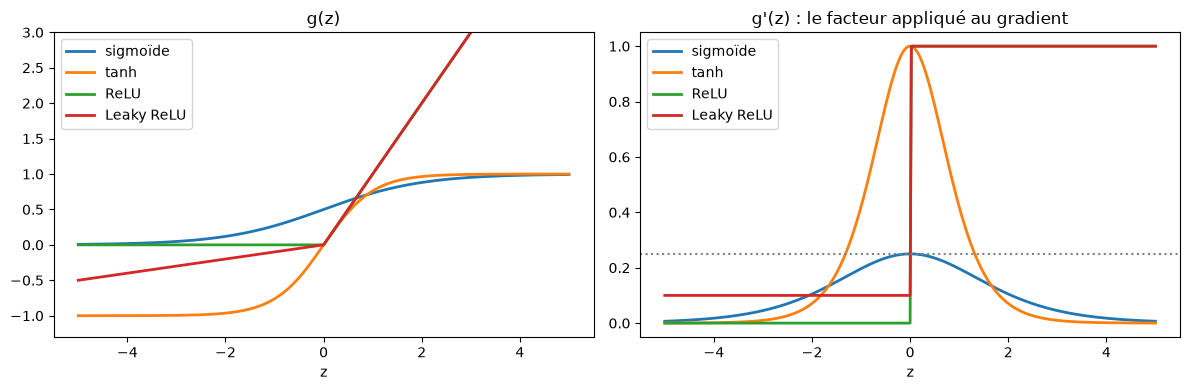

In [18]:
z = np.linspace(-5, 5, 401)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for nom, g, dg in [("sigmoïde", sigmoide, d_sigmoide), ("tanh", tanh, d_tanh),
                   ("ReLU", relu, d_relu), ("Leaky ReLU", leaky_relu, d_leaky_relu)]:
    axes[0].plot(z, g(z), lw=2, label=nom)
    axes[1].plot(z, dg(z), lw=2, label=nom)
axes[0].set(title="g(z)", xlabel="z", ylim=(-1.3, 3))
axes[1].set(title="g'(z) : le facteur appliqué au gradient", xlabel="z")
axes[1].axhline(0.25, color="grey", ls=":")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# TODO :
#  (a) valeur maximale de d_sigmoide sur np.linspace(-6, 6, 1201) ;
#  (b) ce maximum élevé à la puissance 10 (dix couches sigmoïdes, dans le meilleur cas) ;
#  (c) la même chose si chaque unité est à z = 2 (déjà un peu saturée) ;
#  (d) la même chose pour ReLU avec des unités actives (z = 2).

maximum = d_sigmoide(np.linspace(-6, 6, 1201)).max()
print(f"  (a) dérivée maximale de la sigmoïde : {maximum:.4f}")
print(f"  (b) sur 10 couches, au mieux        : {maximum ** 10:.2e}")
print(f"  (c) sur 10 couches à z = 2          : {d_sigmoide(2.0) ** 10:.2e}")
print(f"  (d) ReLU, 10 couches actives        : {d_relu(np.array(2.0)) ** 10:.1f}")

  (a) dérivée maximale de la sigmoïde : 0.2500
  (b) sur 10 couches, au mieux        : 9.54e-07
  (c) sur 10 couches à z = 2          : 1.63e-10
  (d) ReLU, 10 couches actives        : 1.0


# Exercice 1.5 · Empiler des couches linéaires

In [21]:
# TODO :
#  1. avec rng = np.random.default_rng(1), tirez W1 (4, 2), b1 (4,), W2 (1, 4), b2 (1,) ;
#  2. tirez 100 entrées X_alea de forme (100, 2) ;
#  3. calculez deux_couches = (X_alea @ W1.T + b1) @ W2.T + b2 (aucune activation) ;
#  4. calculez W = W2 @ W1, b = W2 @ b1 + b2, puis une_couche = X_alea @ W.T + b ;
#  5. affichez l'écart maximal entre deux_couches et une_couche.

rng = np.random.default_rng(1)
W1_l, b1_l = rng.normal(size=(4, 2)), rng.normal(size=4)
W2_l, b2_l = rng.normal(size=(1, 4)), rng.normal(size=1)
X_alea = rng.normal(size=(100, 2))

deux_couches = (X_alea @ W1_l.T + b1_l) @ W2_l.T + b2_l
# La couche équivalente, calculée une fois pour toutes.
W_eq, b_eq = W2_l @ W1_l, W2_l @ b1_l + b2_l
une_couche = X_alea @ W_eq.T + b_eq
print(f"  écart maximal, 2 couches contre 1 : {np.abs(deux_couches - une_couche).max():.1e}")

# Même chose avec dix couches de largeurs diverses : le produit des matrices suffit.
largeurs = [2, 8, 16, 8, 8, 4, 8, 16, 8, 4, 1]
couches = [(rng.normal(size=(m, n)), rng.normal(size=m))
           for n, m in zip(largeurs[:-1], largeurs[1:])]
sortie = X_alea
W_tot, b_tot = np.eye(2), np.zeros(2)
for W, b in couches:
    sortie = sortie @ W.T + b
    W_tot, b_tot = W @ W_tot, W @ b_tot + b
print(f"  écart maximal, 10 couches contre 1 : "
      f"{np.abs(sortie - (X_alea @ W_tot.T + b_tot)).max():.1e}  "
      f"(relatif {np.abs(sortie - (X_alea @ W_tot.T + b_tot)).max() / np.abs(sortie).max():.1e})")

  écart maximal, 2 couches contre 1 : 4.4e-16
  écart maximal, 10 couches contre 1 : 6.4e-12  (relatif 9.6e-16)


In [24]:
# TODO : pour 5 seeds (random_state=0..4), entraînez sur XOR :
#   A. MLPClassifier(hidden_layer_sizes=(8,) * 10, activation="identity", solver="lbfgs", max_iter=2000)
#   B. MLPClassifier(hidden_layer_sizes=(4,), activation="tanh", solver="lbfgs", max_iter=2000)
#   C. MLPClassifier(hidden_layer_sizes=(4,), activation="relu", solver="lbfgs", max_iter=2000)
# et affichez les 5 valeurs d'accuracy de chacun.

reseaux = {
    "A. 10 couches, identité": dict(hidden_layer_sizes=(8,) * 10, activation="identity"),
    "B. 1 couche de 4, tanh": dict(hidden_layer_sizes=(4,), activation="tanh"),
    "C. 1 couche de 4, ReLU": dict(hidden_layer_sizes=(4,), activation="relu"),
}
for nom, params in reseaux.items():
    exactitudes = [MLPClassifier(solver="lbfgs", max_iter=2000, random_state=g, **params)
                   .fit(X_xor, y_xor).score(X_xor, y_xor) for g in range(5)]
    print(f"  {nom:26s} {exactitudes}")

  A. 10 couches, identité    [0.5, 0.75, 0.5, 0.5, 0.5]
  B. 1 couche de 4, tanh     [1.0, 1.0, 1.0, 1.0, 1.0]
  C. 1 couche de 4, ReLU     [1.0, 1.0, 0.75, 0.75, 0.5]


# Exercice 1.6 · Le forward pass à la main

In [25]:
x = np.array([1.0, 0.0])
y_vrai = 1.0
W1 = np.array([[0.5, -0.5],
               [0.5, 0.5]])
b1 = np.array([0.0, 0.1])
W2 = np.array([[1.0, -1.0]])
b2 = np.array([0.2])

In [26]:
# TODO (1) : sans rien calculer, donnez la forme (un tuple) de chaque quantité.
formes = {"W1": (2, 2), "b1": (2,), "z1": (2,), "a1": (2,),
          "W2": (1, 2), "b2": (1,), "z2": (1,), "a2": (1,)}
# z1 = [0,5*1 + (-0,5)*0 + 0 ; 0,5*1 + 0,5*0 + 0,1] ; les deux sont positifs, ReLU
# les laisse passer ; z2 = 1*0,5 - 1*0,6 + 0,2.
z1_main, a1_main, z2_main = [0.5, 0.6], [0.5, 0.6], 0.1
a2_main, perte_main = 0.525, 0.644

In [27]:
# Vérification : le calcul de référence, fait par NumPy.
z1 = W1 @ x + b1
a1 = np.maximum(0.0, z1)
z2 = W2 @ a1 + b2
a2 = sigmoide(z2)
perte = float(-np.log(a2[0]))
reference = {"W1": W1, "b1": b1, "z1": z1, "a1": a1, "W2": W2, "b2": b2, "z2": z2, "a2": a2}


def verifier(nom, valeur, attendu, tol=2e-3):
    if valeur is None:
        print(f"  {nom:6s} : à compléter")
    elif np.allclose(np.ravel(valeur), np.ravel(attendu), atol=tol):
        print(f"  {nom:6s} : OK")
    else:
        print(f"  {nom:6s} : à revoir (vous : {valeur}, attendu : {np.round(attendu, 6)})")


print("Formes")
for nom, forme in formes.items():
    etat = "à compléter" if forme is None else (
        "OK" if tuple(forme) == reference[nom].shape else f"à revoir ({reference[nom].shape})")
    print(f"  {nom:6s} : {etat}")
print("Valeurs")
for nom, valeur, attendu in [("z1", z1_main, z1), ("a1", a1_main, a1), ("z2", z2_main, z2),
                             ("a2", a2_main, a2), ("loss", perte_main, perte)]:
    verifier(nom, valeur, attendu)
print(f"\nréférence : a2 = {a2[0]:.6f}, loss = {perte:.6f}")

Formes
  W1     : OK
  b1     : OK
  z1     : OK
  a1     : OK
  W2     : OK
  b2     : OK
  z2     : OK
  a2     : OK
Valeurs
  z1     : OK
  a1     : OK
  z2     : OK
  a2     : OK
  loss   : OK

référence : a2 = 0.524979, loss = 0.644397


# Exercice 1.7 · Universal approximation, par construction

In [28]:
xs = np.linspace(-3, 3, 7)
print("  x                   :", xs)
print("  relu(x) + relu(-x)  :", np.maximum(0, xs) + np.maximum(0, -xs))
print("  |x|                 :", np.abs(xs))

  x                   : [-3. -2. -1.  0.  1.  2.  3.]
  relu(x) + relu(-x)  : [3. 2. 1. 0. 1. 2. 3.]
  |x|                 : [3. 2. 1. 0. 1. 2. 3.]


In [29]:
# TODO : complétez reseau_charnieres.
def reseau_charnieres(x, noeuds, cible):
    """Approche `cible` par une somme de ReLU, une unité par point de rupture."""
    valeurs = cible(noeuds)
    pentes = np.diff(valeurs) / np.diff(noeuds)
    # Chaque unité change la pente au moment où elle s'allume.
    coefs = np.r_[pentes[0], np.diff(pentes)]
    x = np.asarray(x, dtype=float)
    return valeurs[0] + sum(c * np.maximum(0.0, x - t) for c, t in zip(coefs, noeuds[:-1]))

In [30]:
# Erreur maximale sur [0, 2π] quand on double le nombre d'unités.
x_fin = np.linspace(0, 2 * np.pi, 4001)
for k in (3, 6, 12, 24, 48):
    noeuds = np.linspace(0, 2 * np.pi, k + 1)
    erreur = np.abs(reseau_charnieres(x_fin, noeuds, np.sin) - np.sin(x_fin)).max()
    print(f"  {k:3d} unités : erreur maximale {erreur:.4f}")

# Hors de la zone : on évalue le réseau à 12 unités sur [2π, 3π].
noeuds12 = np.linspace(0, 2 * np.pi, 13)
x_hors = np.linspace(2 * np.pi, 3 * np.pi, 500)
erreur_hors = np.abs(reseau_charnieres(x_hors, noeuds12, np.sin) - np.sin(x_hors)).max()
print(f"\n  12 unités, hors de la zone [2π, 3π] : erreur maximale {erreur_hors:.2f}")

    3 unités : erreur maximale 0.4373
    6 unités : erreur maximale 0.1340
   12 unités : erreur maximale 0.0329
   24 unités : erreur maximale 0.0085
   48 unités : erreur maximale 0.0021

  12 unités, hors de la zone [2π, 3π] : erreur maximale 3.00


In [32]:
# TODO : déplacez les noeuds intérieurs (gardez 0 et 2π aux extrémités, 9 noeuds).
# Idée : resserrer les noeuds là où la courbure |sin''| = |sin| est forte (vers π/2
# et 3π/2) et les espacer là où la courbe est presque droite (vers 0, π, 2π). On
# répartit les noeuds selon une densité proportionnelle à la racine de la courbure.
grille_fine = np.linspace(0, 2 * np.pi, 10001)
densite = np.sqrt(np.abs(np.sin(grille_fine))) + 0.05
cumul = np.cumsum(densite)
cumul = (cumul - cumul[0]) / (cumul[-1] - cumul[0])
noeuds_perso = np.interp(np.linspace(0, 1, 9), cumul, grille_fine)
erreur_reguliere = np.abs(reseau_charnieres(x_fin, np.linspace(0, 2 * np.pi, 9), np.sin)
                          - np.sin(x_fin)).max()
erreur_perso = np.abs(reseau_charnieres(x_fin, noeuds_perso, np.sin) - np.sin(x_fin)).max()
print(f"  noeuds choisis : {noeuds_perso.round(2)}")
print(f"  espacement régulier : {erreur_reguliere:.4f}   vos noeuds : {erreur_perso:.4f}")

  noeuds choisis : [0.   0.94 1.57 2.2  3.14 4.08 4.71 5.34 6.28]
  espacement régulier : 0.0704   vos noeuds : 0.0507


### TD 2 · Apprendre : la backpropagation, du papier à PyTorch

In [33]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from src.data import SEED, set_seed

set_seed(SEED)
np.set_printoptions(precision=6, suppress=True)
# Quatre threads : sur des tenseurs minuscules, davantage de threads ne fait que
# ralentir (voir TD 3, où ce réglage est expliqué en détail).
torch.set_num_threads(4)

# Les quatre points de XOR, qui serviront à partir de l'exercice 2.3.
X_xor = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = np.array([0.0, 1.0, 1.0, 0.0])


def sigmoide(z):
    return 1.0 / (1.0 + np.exp(-z))


# La fiche de la séance 8 : un exemple, neuf paramètres fixés à la main.
x = np.array([1.0, 0.0])
y_vrai = 1.0
PARAMS = {"W1": np.array([[0.5, -0.5], [0.5, 0.5]]), "b1": np.array([0.0, 0.1]),
          "W2": np.array([[1.0, -1.0]]), "b2": np.array([0.2])}


def perte_fiche(p):
    """Forward pass de la fiche, vu comme une fonction des paramètres."""
    a1 = np.maximum(0.0, p["W1"] @ x + p["b1"])
    a2 = sigmoide(p["W2"] @ a1 + p["b2"])
    return float(-(y_vrai * np.log(a2[0]) + (1 - y_vrai) * np.log(1 - a2[0])))


print(f"loss de la fiche au départ : {perte_fiche(PARAMS):.6f}")

ModuleNotFoundError: No module named 'torch'